In [147]:
import pandas as pd
import re
import numpy as np

# Data Loading and Merging

In [159]:
df = pd.read_csv('../Data/partidos.csv')
df_ranking = pd.read_csv('../Data/ranking_fifa.csv')

/var/folders/5b/g6h6206j3r13bvpzqq54lmf40000gn/T/ipykernel_10627/2000990575.py:1: DtypeWarning: Columns (42,43,44,45,46,47,54,55,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,3

In [ ]:
# Check no duplicates
print(df.shape)
df.drop_duplicates(subset=['URL', 'Fecha', 'Equipo_Local', 'Equipo_Visitante'], keep='last', inplace=True)
print(df.shape)

(3316, 2778)
(3316, 2778)


Vamos a crear un diccionario para poder hacer el join de los datos de FlashScore y el ranking FIFA. 

In [149]:
# CLAVE = Nombre en df_ranking (El que queremos cambiar)
# VALOR = Nombre en df_partidos (El que queremos conservar)
mapeo_paises = {
    'EEUU': 'EE. UU.',
    'RI de Irán': 'Irán',
    'República de Corea': 'Corea del Sur',
    'RD del Congo': 'RD Congo',
    'Bosnia y Herzegovina': 'Bosnia-Herzegovina',
    'Baréin': 'Bahréin',
    'RP China': 'China',
    'República Kirguisa': 'Kirguistán',
    'Kazajstán': 'Kazajistán',
    'RDP de Corea': 'Corea del Norte',
    'Guinea-Bissáu': 'Guinea-Bisáu',
    'San Cristóbal y Nieves': 'Saint Kitts y Nevis',
    'Hong Kong, China': 'Hong Kong',
    'Myanmar': 'Birmania',
    'Esuatini': 'Eswatini',
    'Chinese Taipei': 'China Taipei',
    'Bangladesh': 'Bangladés',
    'Samoa Estadounidense': 'Samoa Americana',
    'Brunéi Darussalam': 'Brunéi',
    'República de Irlanda': 'Irlanda',
    'Qatar': 'Catar',
    'Turcas y Caicos': 'Islas Turcas y Caicos',
    'Antigua y Barbuda': 'Antigua & Barbuda',
    'Comoras': 'Comores'
}

# Aplicar el reemplazo en la columna del df_ranking
df_ranking['País'] = df_ranking['País'].replace(mapeo_paises)

# Comprobar si ha quedado algún país "huérfano"
paises_df = set(df['Equipo_Local'].unique()).union(set(df['Equipo_Visitante'].unique()))
paises_ranking = set(df_ranking['País'].unique())

huérfanos = paises_df - paises_ranking

if huérfanos:
    print(f"ATENCIÓN: Hay {len(huérfanos)} países en tus partidos que NO tienen ranking FIFA asociado:")
    print(sorted(list(huérfanos)))
else:
    print("Éxito! Todos los países de tus partidos tienen su correspondencia exacta en el ranking FIFA.")

ATENCIÓN: Hay 160 países en tus partidos que NO tienen ranking FIFA asociado:
['Afganistán Sub-20', 'Albania Sub-21', 'Alemania Sub-17', 'Alemania Sub-18', 'Alemania Sub-19', 'Arabia Saudí Sub-20', 'Argelia Sub-20', 'Argelia Sub-23', 'Argentina Sub-17', 'Argentina Sub-20', 'Australia Sub-17', 'Australia Sub-20', 'Austria Sub-17', 'Austria Sub-18', 'Bonaire', 'Bosnia-Herzegovina Sub-19', 'Brasil Sub-20', 'Bulgaria Sub-19', 'Bután Sub-23', 'Bélgica Sub-17', 'Bélgica Sub-21', 'Catar Sub-17', 'Catar Sub-20', 'Catar Sub-23', 'Chile Sub-17', 'Chile Sub-20', 'China Sub-20', 'China Sub-23', 'Chipre Sub-19', 'Colombia Sub-20', 'Corea del Norte Sub-23', 'Corea del Sur Sub-17', 'Corea del Sur Sub-23', 'Costa Rica Sub-20', 'Costa de Marfil Sub-20', 'Costa de Marfil Sub-23', 'Croacia Sub-17', 'Croacia Sub-19', 'EE. UU. Sub-18', 'EE. UU. Sub-19', 'EE. UU. Sub-20', 'EE. UU. Sub-21', 'Ecuador Sub-17', 'Egipto Sub-19', 'Egipto Sub-20', 'Emiratos Árabes Unidos Sub-19', 'Emiratos Árabes Unidos Sub-20', '

Unificamos las fechas para el JOIN.

In [150]:
# Gestion de la fecha
# Convierte la columna al formato datetime de Pandas reconociendo los puntos y la hora
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d.%m.%Y %H:%M')

# (Opcional) Si la hora no te aporta nada y quieres quedarte solo con la fecha limpia (YYYY-MM-DD)
df['Fecha'] = df['Fecha'].dt.normalize()
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d')

# Cambiamos el formato de la fecha a YYYY-MM-DD
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha'], format='%d-%m-%Y')
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.strftime('%Y-%m-%d')

# Forzar la conversión de ambas columnas a datetime puro
df['Fecha'] = pd.to_datetime(df['Fecha']).dt.tz_localize(None)
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha']).dt.tz_localize(None)

In [151]:
# ORDENAR por fecha (Obligatorio para merge_asof)
df = df.sort_values('Fecha').reset_index(drop=True)
df_ranking = df_ranking.sort_values('Fecha').reset_index(drop=True)

# ==========================================
# PASO 1: Cruzar ranking del EQUIPO LOCAL
# ==========================================
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Fecha',               # Como se llama igual en ambos, usamos simplemente 'on'
    left_by='Equipo_Local',   
    right_by='País',          
    direction='backward',     
    allow_exact_matches=False 
)

# Renombramos SOLO los datos del ranking, dejando la 'Fecha' intacta
df = df.rename(columns={
    'Puntuación': 'Puntos_Local'  # O la variable que tengas de puntos
})

# ==========================================
# PASO 2: Cruzar ranking del EQUIPO VISITANTE
# ==========================================
df = pd.merge_asof(
    df, 
    df_ranking,
    on='Fecha',               # La columna 'Fecha' sigue ahí, lista para usarse
    left_by='Equipo_Visitante',
    right_by='País',
    direction='backward',
    allow_exact_matches=False 
)

# Renombramos los datos del Visitante
df = df.rename(columns={
    'Puntuación': 'Puntos_Visitante'
})

# Opcional: Como el 'País' del df_ranking se nos pegará dos veces, lo limpiamos
columnas_a_borrar = [col for col in df.columns if 'País' in col]
df = df.drop(columns=columnas_a_borrar)

# Comprobamos el JOIN
print(df[['Fecha', 'Equipo_Local', 'Puntos_Local', 'Equipo_Visitante', 'Puntos_Visitante']].head())

       Fecha Equipo_Local  Puntos_Local Equipo_Visitante  Puntos_Visitante
0 2019-06-06     Mongolia         915.0           Brunéi             903.0
1 2019-06-06        Macao         925.0        Sri Lanka             886.0
2 2019-06-06         Laos         923.0        Bangladés             907.0
3 2019-06-06      Camboya         970.0         Pakistán             888.0
4 2019-06-06        Bután         917.0             Guam             907.0


Vamos a agrupar los países por continetne para poder utilizar esta variable para modelizar (no es lo mismo enfrentarte normalmente a equipos de África que de Europa).

Shout out to Claude por el diccionario.

In [152]:
mapa_continentes = {
    # EUROPA (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa',
    
    # SUDAMÉRICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    
    # NORTEAMÉRICA Y CARIBE (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    
    # ÁFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa',
    
    # ASIA (AFC) - Nota: Australia compite deportivamente en Asia
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia'
}

In [153]:
# Aplicamos el diccionario para crear la nueva columna
df['Continente_Local'] = df['Equipo_Local'].map(mapa_continentes)
df['Continente_Visitante'] = df['Equipo_Visitante'].map(mapa_continentes)

Creamos una variable que pondere los datos por continente, para intentar compensar el efecto de jugar en distintos continentes de forma habitual. 

In [154]:
pesos_continente = {
    'Europa': 1.00,       # No se descuenta nada
    'Sudamérica': .95,   # Se descuenta un 5%
    'Norteamérica': 0.75, # Se les quita un 25% de su poder ofensivo
    'Africa': 0.6,
    'Asia': 0.7,         # Se les quita un 30% 
    'Oceanía': 0.5       # Sus medias valen la mitad en un Mundial
}

# Aplicas el descuento en tu código:
df['Peso_Local'] = df['Continente_Local'].map(pesos_continente)
df['Peso_Visitante'] = df['Continente_Visitante'].map(pesos_continente)

df.drop(['Continente_Local', 'Continente_Visitante'], axis = 1)

df.head()

Unnamed: 0      Fecha                                                URL  \
0        2542 2019-06-06  https://www.flashscore.es/partido/futbol/brune...   
1        2541 2019-06-06  https://www.flashscore.es/partido/futbol/macao...   
2        2540 2019-06-06  https://www.flashscore.es/partido/futbol/bangl...   
3        2539 2019-06-06  https://www.flashscore.es/partido/futbol/cambo...   
4        2538 2019-06-06  https://www.flashscore.es/partido/futbol/butan...   

  Equipo_Local Equipo_Visitante      Resultado  Goles_esperados_(xG)_Local  \
0     Mongolia           Brunéi  2-0Finalizado                         NaN   
1        Macao        Sri Lanka  1-0Finalizado                         NaN   
2         Laos        Bangladés  0-1Finalizado                         NaN   
3      Camboya         Pakistán  2-0Finalizado                         NaN   
4        Bután             Guam  1-0Finalizado                         NaN   

   Goles_esperados_(xG)_Visitante Posesión_Local Posesión_Visitante  \
0                             NaN            NaN                NaN   
1                             NaN            NaN                NaN   
2                             NaN            NaN                NaN   
3                             NaN            NaN                NaN   
4                             NaN            NaN                NaN   

   Remates_totales_Local  Remates_totales_Visitante  Remates_a_puerta_Local  \
0                    NaN                        NaN                     NaN   
1                    NaN                        NaN                     NaN   
2                    NaN                        NaN                     NaN   
3                    NaN                        NaN                     NaN   
4                    NaN                        NaN                     NaN   

   Remates_a_puerta_Visitante  Grandes_ocasiones_Local  \
0                         NaN                      NaN   
1                         NaN                      NaN   
2                         NaN                      NaN   
3                         NaN                      NaN   
4                         NaN                      NaN   

   Grandes_ocasiones_Visitante  Córneres_Local  Córneres_Visitante  \
0                          NaN             NaN                 NaN   
1                          NaN             NaN                 NaN   
2                          NaN             NaN                 NaN   
3                          NaN             NaN                 NaN   
4                          NaN             NaN                 NaN   

  Pases_Local Pases_Visitante  Tarjetas_amarillas_Local  \
0         NaN             NaN                       NaN   
1         NaN             NaN                       NaN   
2         NaN             NaN                       NaN   
3         NaN             NaN                       NaN   
4         NaN             NaN                       NaN   

   Tarjetas_amarillas_Visitante  xG_a_puerta_(xGOT)_Local  \
0                           NaN                       NaN   
1                           NaN                       NaN   
2                           NaN                       NaN   
3                           NaN                       NaN   
4                           NaN                       NaN   

   xG_a_puerta_(xGOT)_Visitante  Remates_fuera_Local  Remates_fuera_Visitante  \
0                           NaN                  NaN                      NaN   
1                           NaN                  NaN                      NaN   
2                           NaN                  NaN                      NaN   
3                           NaN                  NaN                      NaN   
4                           NaN                  NaN                      NaN   

   Remates_rechazados_Local  Remates_rechazados_Visitante  \
0                       NaN                           NaN   
1                       NaN                           Na

# Data Cleaning

In [155]:
print(df.shape)

# Definimos las condiciones: queremos las filas que NO (~) contengan "sub" (eliminar sub20, sub17, etc)
# Usamos na=False por si alguna celda está vacía, para que no de error
filtro_local = ~df['Equipo_Local'].astype(str).str.contains('sub', case=False, na=False)
filtro_visitante = ~df['Equipo_Visitante'].astype(str).str.contains('sub', case=False, na=False)

# Filtramos el dataset aplicando ambas condiciones a la vez (con el operador &)
df = df[filtro_local & filtro_visitante]

# Reiniciamos el índice para que vuelva a ser correlativo tras borrar filas
df = df.reset_index(drop=True)
print(df.shape)
df.head()

(3316, 2784)
(3144, 2784)


Unnamed: 0      Fecha                                                URL  \
0        2542 2019-06-06  https://www.flashscore.es/partido/futbol/brune...   
1        2541 2019-06-06  https://www.flashscore.es/partido/futbol/macao...   
2        2540 2019-06-06  https://www.flashscore.es/partido/futbol/bangl...   
3        2539 2019-06-06  https://www.flashscore.es/partido/futbol/cambo...   
4        2538 2019-06-06  https://www.flashscore.es/partido/futbol/butan...   

  Equipo_Local Equipo_Visitante      Resultado  Goles_esperados_(xG)_Local  \
0     Mongolia           Brunéi  2-0Finalizado                         NaN   
1        Macao        Sri Lanka  1-0Finalizado                         NaN   
2         Laos        Bangladés  0-1Finalizado                         NaN   
3      Camboya         Pakistán  2-0Finalizado                         NaN   
4        Bután             Guam  1-0Finalizado                         NaN   

   Goles_esperados_(xG)_Visitante Posesión_Local Posesión_Visitante  \
0                             NaN            NaN                NaN   
1                             NaN            NaN                NaN   
2                             NaN            NaN                NaN   
3                             NaN            NaN                NaN   
4                             NaN            NaN                NaN   

   Remates_totales_Local  Remates_totales_Visitante  Remates_a_puerta_Local  \
0                    NaN                        NaN                     NaN   
1                    NaN                        NaN                     NaN   
2                    NaN                        NaN                     NaN   
3                    NaN                        NaN                     NaN   
4                    NaN                        NaN                     NaN   

   Remates_a_puerta_Visitante  Grandes_ocasiones_Local  \
0                         NaN                      NaN   
1                         NaN                      NaN   
2                         NaN                      NaN   
3                         NaN                      NaN   
4                         NaN                      NaN   

   Grandes_ocasiones_Visitante  Córneres_Local  Córneres_Visitante  \
0                          NaN             NaN                 NaN   
1                          NaN             NaN                 NaN   
2                          NaN             NaN                 NaN   
3                          NaN             NaN                 NaN   
4                          NaN             NaN                 NaN   

  Pases_Local Pases_Visitante  Tarjetas_amarillas_Local  \
0         NaN             NaN                       NaN   
1         NaN             NaN                       NaN   
2         NaN             NaN                       NaN   
3         NaN             NaN                       NaN   
4         NaN             NaN                       NaN   

   Tarjetas_amarillas_Visitante  xG_a_puerta_(xGOT)_Local  \
0                           NaN                       NaN   
1                           NaN                       NaN   
2                           NaN                       NaN   
3                           NaN                       NaN   
4                           NaN                       NaN   

   xG_a_puerta_(xGOT)_Visitante  Remates_fuera_Local  Remates_fuera_Visitante  \
0                           NaN                  NaN                      NaN   
1                           NaN                  NaN                      NaN   
2                           NaN                  NaN                      NaN   
3                           NaN                  NaN                      NaN   
4                           NaN                  NaN                      NaN   

   Remates_rechazados_Local  Remates_rechazados_Visitante  \
0                       NaN                           NaN   
1                       NaN                           Na

El scrapper se ha descragado muchísimas variables, algunas de las cuales no queremos utilizar por estar poco informadas o no asumir que vayan a tener poder predictivo, así que las eliminamos. También eliminamos columnas que no interesan del scrapper y algunas variables por estar correladas con otras (Por ejemplo Remates_total y Remates_a_puerta).

In [156]:
# Definir la lista estricta de variables para el modelo
# Omitimos algunas interesantes por estar incompletas o no ser tan relevantes para el modelo
columnas = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 
    'Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 
    'Posesión_Local', 'Posesión_Visitante', 
    # 'Remates_totales_Local', 'Remates_totales_Visitante', 
    'Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 
    # 'Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 
    'Córneres_Local', 'Córneres_Visitante', 
    'Pases_Local', 'Pases_Visitante', 
    'Tarjetas_amarillas_Local', 'Tarjetas_amarillas_Visitante',
    # 'Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 
    # 'Fueras_de_juego_Local', 'Fueras_de_juego_Visitante', 
    # 'Tiros_libres_Local', 'Tiros_libres_Visitante', 
    # 'Pases_en_el_tercio_final_Local', 'Pases_en_el_tercio_final_Visitante', 
    # 'Saques_de_banda_Local', 'Saques_de_banda_Visitante', 
    'Faltas_Local', 'Faltas_Visitante', 
    # 'Entradas_Local', 'Entradas_Visitante', 
    # 'Duelos_ganados_Local', 'Duelos_ganados_Visitante', 
    'Paradas_Local', 'Paradas_Visitante',
    'Puntos_Local', 'Puntos_Visitante',
    'Peso_Local', 'Peso_Visitante'
]

# Filtrado mediante comprensión de listas
columnas_existentes = [col for col in columnas if col in df.columns]

# Sobrescribir el DataFrame con el subconjunto validado
df = df[columnas_existentes]

In [157]:
# Comprobar el dataset que hemos obtenido
pd.set_option('display.max_columns', None)
print(df.shape)
df.iloc[1000:1003]

(3144, 24)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Pases_Local,Pases_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante
1000,2022-06-14,Bosnia-Herzegovina,Finlandia,3-2Finalizado,NaN,NaN,42%,58%,7.0,3.0,9.0,4.0,83%(293/351),87%(473/541),2.0,1.0,11.0,5.0,1.0,4.0,1388.63,1406.87,1.0,NaN
1001,2022-06-14,Rumanía,Montenegro,0-3Finalizado,NaN,NaN,60%,40%,2.0,3.0,2.0,5.0,83%(372/446),72%(217/300),4.0,3.0,13.0,13.0,0.0,2.0,1446.54,1342.79,NaN,NaN
1002,2022-06-14,Alemania,Italia,5-2Finalizado,NaN,NaN,64%,36%,9.0,6.0,5.0,4.0,91%(610/672),82%(300/364),2.0,0.0,8.0,7.0,4.0,4.0,1650.53,1723.31,1.0,NaN


Ahora nos quedamos solo con partidos en los que participe alguno de los equipos del Mundial, ya que el resto no nos interesa. 

In [158]:
# Dataset con los partidos del mundial (fase de grupos)
df_2026 = df[df['Fecha'] > pd.to_datetime('2026-06-10')].copy()

# Guardamos el dataset para hacer las predicciones en la fase de grupos
df_2026.to_csv('../Data/partidos_mundial.csv')

In [116]:
# Solo paises en el mundial para no distorsionar
df = df[df['Equipo_Local'].isin(df_2026['Equipo_Local']) | df['Equipo_Visitante'].isin(df_2026['Equipo_Visitante'])]
print(df.shape)

(1660, 24)


Para que los equipos sean lo más parecidos posible a lo que veremos en el Mundial filtramos las fechas más antiguas. 

Además, datos como xG no están disponibles para fechas muy antiguas.

In [117]:
# Cortamos fechas muy antiguas (poca info)
fecha_corte = pd.to_datetime('2021-01-01')
df = df[df['Fecha'] >= fecha_corte].copy()
print(df.shape)
df.head()

(1604, 24)


,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Pases_Local,Pases_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante
160,2021-03-24,Bélgica,Gales,3-1Finalizado,NaN,NaN,71%,29%,4.0,1.0,4.0,1.0,91%(814/897),77%(235/304),1.0,0.0,12.0,3.0,0.0,1.0,1780.0,1562.0,1.0,NaN
162,2021-03-24,Eslovenia,Croacia,1-0Finalizado,NaN,NaN,34%,66%,2.0,4.0,2.0,4.0,76%(239/313),89%(626/700),2.0,5.0,11.0,15.0,4.0,1.0,1379.0,1617.0,NaN,1.0
163,2021-03-24,Estonia,República Checa,2-6Finalizado,NaN,NaN,30%,70%,3.0,8.0,0.0,6.0,62%(144/233),90%(658/735),NaN,NaN,10.0,14.0,2.0,1.0,1180.0,1456.0,NaN,1.0
164,2021-03-24,Finlandia,Bosnia-Herzegovina,2-2Finalizado,NaN,NaN,45%,55%,7.0,8.0,5.0,7.0,84%(374/447),86%(497/578),3.0,0.0,11.0,11.0,6.0,5.0,1411.0,1410.0,NaN,1.0
165,2021-03-24,Francia,Ucrania,1-1Finalizado,NaN,NaN,62%,38%,3.0,1.0,12.0,0.0,91%(753/829),84%(402/478),1.0,0.0,17.0,3.0,0.0,2.0,1755.0,1521.0,1.0,NaN


## Construcción de variables

Algunas variables vienen en formatos "raros" al hacer el scrapping. Por ejemplo, ``Pases_Local`` viene como `91%(814/897)`. Vamos a extraer los distintos datos para tener unas variables que podamos utilizar para la modelización.

### Limpieza del resultado

In [118]:
def limpiar_resultados_flashscore(texto):
    texto = str(texto).strip()
    
    # 1. Caso: Partido resuelto en 90 minutos (Ej: "2-1Finalizado")
    match_fin = re.match(r'^(\d+-\d+)\s*Finalizado', texto)
    if match_fin:
        resultado_90 = match_fin.group(1)
        return pd.Series([resultado_90, None, None])
        
    # 2. Caso: Partido resuelto en Prórroga (Ej: "1-0(0-0)Tras la prórroga")
    # Capturamos el 1-0 como final y el 0-0 como tiempo regular
    match_pro = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras la prórroga', texto)
    if match_pro:
        resultado_120 = match_pro.group(1) # El resultado final tras los 120 min (1-0)
        resultado_90 = match_pro.group(2)  # El resultado a los 90 min (0-0)
        
        # CORRECCIÓN: Asignamos el empate (0-0) como Resultado principal de los 90 min
        # y guardamos el 1-0 en la columna de Prórroga
        return pd.Series([resultado_90, resultado_120, None])
        
    # 3. Caso: Partido resuelto en Penaltis (Ej: "2-1(1-1)Tras los penaltis")
    match_pen = re.match(r'^(\d+-\d+)\s*\(\s*(\d+-\d+)\s*\)\s*Tras los penaltis', texto)
    if match_pen:
        resultado_penaltis = match_pen.group(1) # El resultado de la tanda (2-1)
        resultado_120 = match_pen.group(2)      # El resultado del partido jugado (1-1)
        
        # Asignamos el empate (1-1) como Resultado principal
        return pd.Series([resultado_120, resultado_120, resultado_penaltis])
        
    # 4. Caso residual (aplazados, suspendidos, u otros textos)
    return pd.Series([texto, None, None])

# Aplicamos la función
nuevas_columnas = ['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']
df[nuevas_columnas] = df['Resultado'].apply(limpiar_resultados_flashscore)

print(df[['Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis']].head())

    Resultado Resultado_Prorroga Resultado_Penaltis
160       3-1               None               None
162       1-0               None               None
163       2-6               None               None
164       2-2               None               None
165       1-1               None               None


### Limpieza de variables con (%)

In [119]:
# Especifica las columnas que tienen este formato complejo
columnas_combinadas = ['Pases_Local', 'Pases_Visitante'] # 'Pases_en_el_tercio_final_Local', 'Pases_en_el_tercio_final_Visitante', 'Entradas_Local', 'Entradas_Visitante' 

for col in columnas_combinadas:
    extraccion = df[col].astype(str).str.extract(r'(\d+)%\((\d+)/\d+\)')
    
    # Creamos dos nuevas columnas a partir de la extracción y las pasamos a numérico.
    df[f"{col}_Pct"] = pd.to_numeric(extraccion[0], errors='coerce')
    df[f"{col}_Exitosos"] = pd.to_numeric(extraccion[1], errors='coerce')

# Opcional: Ver el resultado y borrar la columna original sucia
print(df[[f"{columnas_combinadas[0]}_Pct", f"{columnas_combinadas[0]}_Exitosos"]].head())

df = df.drop(columns=columnas_combinadas) # Descomenta esto si quieres borrar las originales

     Pases_Local_Pct  Pases_Local_Exitosos
160             91.0                 814.0
162             76.0                 239.0
163             62.0                 144.0
164             84.0                 374.0
165             91.0                 753.0


In [120]:
# Lista con los nombres de las columnas que contienen porcentajes
columnas_porcentaje = ['Posesión_Local', 'Posesión_Visitante', 'Pases_Local_Pct', 'Pases_Visitante_Pct'] # 'Pases_en_el_tercio_final_Local_Pct', 'Pases_en_el_tercio_final_Visitante_Pct', 'Entradas_Local_Pct', 'Entradas_Visitante_Pct'

for col in columnas_porcentaje:
    df[col] = df[col].astype(str).str.replace('%', '').astype(float) / 100

# Verificamos el resultado
print(df[['Posesión_Local', 'Posesión_Visitante']].head())

     Posesión_Local  Posesión_Visitante
160            0.71                0.29
162            0.34                0.66
163            0.30                0.70
164            0.45                0.55
165            0.62                0.38


## Data Split

Vamos a separar los datos antes del mundial y después para tener un dataset para entrenar por un lado y el del mundial por el otro para cuando hagamos las predicciones y las simulaciones. 

In [121]:
# --- Guardamos dataset del mundial 
print(f"Filas totales originales: {len(df)}")

# 1. Definimos la fecha que actuará como frontera
fecha_corte = pd.to_datetime('2026-06-10')

# 2. Creamos el dataset con los datos DESPUÉS (o el mismo día) de la fecha de corte
# Usamos mayor o igual (>=) para no perder los partidos que se jueguen ese mismo día
df_mundial = df[df['Fecha'] >= fecha_corte].copy()
df_mundial.to_csv('../Data/partidos_mundial.csv', index=False)

# 3. Creamos el dataset con los datos ANTES de la fecha de corte
# Usamos estrictamente menor (<)
# La idea es hacer la limpieza en este dataset y que no se ensucie por la muestra del mundial
df = df[df['Fecha'] < fecha_corte].copy()

# Comprobación de que no hemos perdido filas por el camino
print(f"Filas en df_antes: {len(df)}")
print(f"Filas en df_despues: {len(df_mundial)}")

Filas totales originales: 1604
Filas en df_antes: 1532
Filas en df_despues: 72


## Comprobación de nulos

In [122]:
# Variables con nulos
df.isnull().sum()

Fecha                                0
Equipo_Local                         0
Equipo_Visitante                     0
Resultado                            0
Goles_esperados_(xG)_Local         899
Goles_esperados_(xG)_Visitante     899
Posesión_Local                     136
Posesión_Visitante                 136
Remates_a_puerta_Local             136
Remates_a_puerta_Visitante         136
Córneres_Local                     136
Córneres_Visitante                 136
Tarjetas_amarillas_Local           209
Tarjetas_amarillas_Visitante       209
Faltas_Local                       206
Faltas_Visitante                   206
Paradas_Local                      167
Paradas_Visitante                  167
Puntos_Local                         2
Puntos_Visitante                     4
Peso_Local                         560
Peso_Visitante                     622
Resultado_Prorroga                1489
Resultado_Penaltis                1500
Pases_Local_Pct                    337
Pases_Local_Exitosos     

Consideramos la variable Posesión para eliminar filas con NAs. Esto se debe a que este es el dato más básico de estadísticas del partido. Si no tenemos este dato disponible, asumimos que no tendremos información útil para modelar y por tanto mejor obviar estas observaciones. 

In [123]:
# 1. Columnas que DEBEN estar completas
columnas_obligatorias = ['Posesión_Visitante', 'Posesión_Local'] 

# 2. Borramos las filas que tengan al menos un NA en las columnas obligatorias
df = df.dropna(subset=columnas_obligatorias)

# Reiniciar el índice tras borrar filas
df = df.reset_index(drop=True)

# Dataset restante tras eliminar filas con NAs en columnas críticas
print(df.shape)

# Check
df.isnull().sum()

(1396, 28)


Fecha                                0
Equipo_Local                         0
Equipo_Visitante                     0
Resultado                            0
Goles_esperados_(xG)_Local         763
Goles_esperados_(xG)_Visitante     763
Posesión_Local                       0
Posesión_Visitante                   0
Remates_a_puerta_Local               0
Remates_a_puerta_Visitante           0
Córneres_Local                       0
Córneres_Visitante                   0
Tarjetas_amarillas_Local            74
Tarjetas_amarillas_Visitante        74
Faltas_Local                        70
Faltas_Visitante                    70
Paradas_Local                       31
Paradas_Visitante                   31
Puntos_Local                         0
Puntos_Visitante                     1
Peso_Local                         509
Peso_Visitante                     564
Resultado_Prorroga                1353
Resultado_Penaltis                1364
Pases_Local_Pct                    201
Pases_Local_Exitosos     

# Data Imputation

Para no quedarnos sin muestra, vamos a imputar los nulos utilizando la `IterativeImputer` de ``sklearn``. Esta es una opción avanzada, pero dado que la idea del Notebook es aprneder y divulgar utilizamos este método. 

Los parámetros no están optimizados al extremo, aquí buscamos simplemente tener un dataset completo y razonable sin buscar ser perfecto. 

In [124]:
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Separamos el dataset: columnas intocables (texto/identificadores) y columnas a imputar
columnas_texto = ['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis'] 
columnas_numericas = [col for col in df.columns if col not in columnas_texto]

# 2. Configuramos el Imputador
# Usamos RandomForest internamente porque capta muy bien las relaciones no lineales del fútbol
imputador = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42,
    min_value=0  # Nadie puede tener -2 remates o -0.5 xG
)

# 3. Entrenamos y aplicamos la imputación solo sobre las variables numéricas
df_imputado = pd.DataFrame(
    imputador.fit_transform(df[columnas_numericas]), 
    columns=columnas_numericas, 
    index=df.index
)

# 4. Volvemos a unir las columnas de texto intactas con los números ya limpios
df = pd.concat([df[columnas_texto], df_imputado], axis=1)

# Comprobación de que hemos aniquilado los NAs
print(df.isna().sum())

Fecha                                0
Equipo_Local                         0
Equipo_Visitante                     0
Resultado                            0
Resultado_Prorroga                1353
Resultado_Penaltis                1364
Goles_esperados_(xG)_Local           0
Goles_esperados_(xG)_Visitante       0
Posesión_Local                       0
Posesión_Visitante                   0
Remates_a_puerta_Local               0
Remates_a_puerta_Visitante           0
Córneres_Local                       0
Córneres_Visitante                   0
Tarjetas_amarillas_Local             0
Tarjetas_amarillas_Visitante         0
Faltas_Local                         0
Faltas_Visitante                     0
Paradas_Local                        0
Paradas_Visitante                    0
Puntos_Local                         0
Puntos_Visitante                     0
Peso_Local                           0
Peso_Visitante                       0
Pases_Local_Pct                      0
Pases_Local_Exitosos     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Para tener disponibles las variables que creemos para hacer predicciones para el mundial, vamos a añadir a nuestro dataframe una fila con el primer partido de cada equipo en el Mundial. De esta forma, tenemos una fila auxiliar que contendrá las medias móviles de esa selección hasta justo antes del Mundial. Esta será la información que utilizaremos para simular el Mundial después (ya que es toda la info actualizada que tenemos). Por ejemplo, para España, tendremos una fila extra con su primer partido en el Mundial que contendrá las medias móviles de nuestras variables hasta antes del Mundial. 

In [125]:
# Dataset con el primer partido del mundial para cada equipo
# Lo utilizaremos para tener los datos para las predicciones en el mundial

# 1. Asegurar el orden cronológico
df_mundial = df_mundial.sort_values('Fecha').reset_index(drop=True)

equipos_vistos = set()
indices_debuts = []

# 2. Rastrear el primer partido de cada equipo
for idx, row in df_mundial.iterrows():
    local = row['Equipo_Local']
    visitante = row['Equipo_Visitante']
    
    # Si el local O el visitante no han sido vistos antes, este partido es el debut de alguno de ellos
    if local not in equipos_vistos or visitante not in equipos_vistos:
        indices_debuts.append(idx)
        equipos_vistos.add(local)
        equipos_vistos.add(visitante)

# 3. Filtrar el DataFrame original con los índices guardados
df_mundial_first = df_mundial.iloc[indices_debuts].copy().reset_index(drop=True)

print(f"Partidos de debut extraídos: {len(df_mundial_first)}")

Partidos de debut extraídos: 24


In [126]:
# Creamos dataset incluyendo el primer partido del mundial para predecirlo
df = pd.concat([df, df_mundial_first], ignore_index=True)
df.tail()

,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos
1415,2026-06-17,Irak,Noruega,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1447.14,1550.94,0.70,1.00,NaN,NaN,NaN,NaN
1416,2026-06-17,Argentina,Argelia,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1874.81,1564.26,0.95,0.60,NaN,NaN,NaN,NaN
1417,2026-06-17,Austria,Jordania,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1593.45,1391.45,1.00,0.70,NaN,NaN,NaN,NaN
1418,2026-06-18,Ghana,Panamá,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1346.31,1540.64,0.60,0.75,NaN,NaN,NaN,NaN
1419,2026-06-18,Uzbekistán,Colombia,nan,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1465.34,1693.09,0.70,0.95,NaN,NaN,NaN,NaN


# Feature Engineering

A partir de todas las variables que tenemos en nuestro dataset, vamos a construir variables que puedan ser interesantes a partir de estas. 

In [127]:
df[["Goles_Local", "Goles_Visitante"]] = df["Resultado"].str.split("-", expand=True)
df["Goles_Local"] = pd.to_numeric(df["Goles_Local"], errors="coerce")
df["Goles_Visitante"] = pd.to_numeric(df["Goles_Visitante"], errors="coerce")

df["Resultado_1X2"] = df.apply(lambda row: "1" if row["Goles_Local"] > row["Goles_Visitante"] 
                                         else ("X" if row["Goles_Local"] == row["Goles_Visitante"] else "2"), axis=1)

df["Ptos_Local"] = df.apply(lambda row: 3 if row["Goles_Local"] > row["Goles_Visitante"] 
                                         else (1 if row["Goles_Local"] == row["Goles_Visitante"] else 0), axis=1)

# puntos visitante
df["Ptos_Visitante"] = df.apply(lambda row: 3 if row["Goles_Visitante"] > row["Goles_Local"] 
                                     else (1 if row["Goles_Visitante"] == row["Goles_Local"] else 0), axis=1)

df.head()

,Fecha,Equipo_Local,Equipo_Visitante,Resultado,Resultado_Prorroga,Resultado_Penaltis,Goles_esperados_(xG)_Local,Goles_esperados_(xG)_Visitante,Posesión_Local,Posesión_Visitante,Remates_a_puerta_Local,Remates_a_puerta_Visitante,Córneres_Local,Córneres_Visitante,Tarjetas_amarillas_Local,Tarjetas_amarillas_Visitante,Faltas_Local,Faltas_Visitante,Paradas_Local,Paradas_Visitante,Puntos_Local,Puntos_Visitante,Peso_Local,Peso_Visitante,Pases_Local_Pct,Pases_Local_Exitosos,Pases_Visitante_Pct,Pases_Visitante_Exitosos,Goles_Local,Goles_Visitante,Resultado_1X2,Ptos_Local,Ptos_Visitante
0,2021-03-24,Bélgica,Gales,3-1,None,None,1.747,0.356,0.71,0.29,4.0,1.0,4.0,1.0,1.0,0.0,12.0,3.0,0.0,1.0,1780.0,1562.0,1.000,0.870,0.91,814.0,0.77,235.0,3.0,1.0,1,3,0
1,2021-03-24,Eslovenia,Croacia,1-0,None,None,0.543,1.124,0.34,0.66,2.0,4.0,2.0,4.0,2.0,5.0,11.0,15.0,4.0,1.0,1379.0,1617.0,0.885,1.000,0.76,239.0,0.89,626.0,1.0,0.0,1,3,0
2,2021-03-24,Estonia,República Checa,2-6,None,None,0.484,3.188,0.30,0.70,3.0,8.0,0.0,6.0,2.1,1.9,10.0,14.0,2.0,1.0,1180.0,1456.0,0.795,1.000,0.62,144.0,0.90,658.0,2.0,6.0,2,0,3
3,2021-03-24,Finlandia,Bosnia-Herzegovina,2-2,None,None,0.997,1.752,0.45,0.55,7.0,8.0,5.0,7.0,3.0,0.0,11.0,11.0,6.0,5.0,1411.0,1410.0,0.975,1.000,0.84,374.0,0.86,497.0,2.0,2.0,X,1,1
4,2021-03-24,Francia,Ucrania,1-1,None,None,1.476,0.391,0.62,0.38,3.0,1.0,12.0,0.0,1.0,0.0,17.0,3.0,0.0,2.0,1755.0,1521.0,1.000,0.855,0.91,753.0,0.84,402.0,1.0,1.0,X,1,1


Vamos a construir variables de tipo "Share". Básicamente, del todal de disparos, que porcentaje fueron del local y cual del visitante. Estas variables suelen funcionar muy bien en deportes, y es que indica el "poder ofensivo" de un equipo no en términos absolutos si no relatvios dentro del partido. 

In [128]:
# Estructura: (Nombre Columna Local, Nombre Columna Visitante, Nombre para la nueva métrica)
pares_metricas = [
    ('Goles_esperados_(xG)_Local', 'Goles_esperados_(xG)_Visitante', 'xG'),
    # ('Remates_totales_Local', 'Remates_totales_Visitante', 'Remates_Totales'),
    ('Remates_a_puerta_Local', 'Remates_a_puerta_Visitante', 'Remates_Puerta'),
    # ('Grandes_ocasiones_Local', 'Grandes_ocasiones_Visitante', 'Grandes_Ocasiones'),
    ('Córneres_Local', 'Córneres_Visitante', 'Corneres'),
    # ('Toques_en_el_área_rival_Local', 'Toques_en_el_área_rival_Visitante', 'Toques_Area_Rival'),
    # ('Duelos_ganados_Local', 'Duelos_ganados_Visitante', 'Duelos_Ganados'),
    ('Paradas_Local', 'Paradas_Visitante', 'Paradas'), # Nota: Un share alto aquí indica que fuiste dominado
    ('Pases_Local_Exitosos', 'Pases_Visitante_Exitosos', 'Pases_Exitosos'),
    # ('Pases_en_el_tercio_final_Local_Exitosos', 'Pases_en_el_tercio_final_Visitante_Exitosos', 'Pases_Tercio_Final'),
    # ('Entradas_Local_Exitosos', 'Entradas_Visitante_Exitosos', 'Entradas_Exitosas'),
    ('Goles_Local', 'Goles_Visitante', 'Goles'),
    ('Puntos_Local', 'Puntos_Visitante', 'Puntos')
]

for col_local, col_visitante, nombre_base in pares_metricas:
    # 1. Calculamos el volumen total de la métrica en el partido
    suma_total = df[col_local] + df[col_visitante]
    
    # 2. Calculamos el Share del Local
    # np.where(condición, valor_si_verdadero, valor_si_falso)
    df[f'{nombre_base}_Share_Local'] = np.where(
        suma_total > 0,
        df[col_local] / suma_total,
        0.5  # Asignamos 0.5 si la suma es 0 (ej: 0 goles de ambos = partido igualado)
    )
    
    # 3. El Share del Visitante es matemáticamente el inverso (1 - Local)
    df[f'{nombre_base}_Share_Visitante'] = 1 - df[f'{nombre_base}_Share_Local']

# Visualizamos una muestra de las nuevas columnas generadas
columnas_generadas = [f"{t[2]}_Share_Local" for t in pares_metricas]

# Check 
df[['Equipo_Local', 'Equipo_Visitante', 'Resultado'] + columnas_generadas].head()

,Equipo_Local,Equipo_Visitante,Resultado,xG_Share_Local,Remates_Puerta_Share_Local,Corneres_Share_Local,Paradas_Share_Local,Pases_Exitosos_Share_Local,Goles_Share_Local,Puntos_Share_Local
0,Bélgica,Gales,3-1,0.830718,0.800000,0.800000,0.000000,0.775977,0.75,0.532615
1,Eslovenia,Croacia,1-0,0.325735,0.333333,0.333333,0.800000,0.276301,1.00,0.460280
2,Estonia,República Checa,2-6,0.131808,0.272727,0.000000,0.666667,0.179551,0.25,0.447648
3,Finlandia,Bosnia-Herzegovina,2-2,0.362677,0.466667,0.416667,0.545455,0.429392,0.50,0.500177
4,Francia,Ucrania,1-1,0.790573,0.750000,1.000000,0.000000,0.651948,0.50,0.535714


### Medias móviles

No podemos utilizar las estadísticas de un partido para predecir el resultado ya que solo se conocen una vez termina el partido (tendríamos fuga de datos de hacer esto).

Para solventar esto, lo que haremos es calcular medias móviles de los partidos previos para capturar la forma, tendencia y poder de cada selección en los partidos previos para intentar predecir el siguiente. 

Comenzamos crendo un dataset en donde "omitimos" el Local/Visitante, concatenando las estadísticas de los partidos sin tener en cuenta el Local/Visitante. Así, la media móvil captura la forma más reciente overall y no solo de los partidos en los que la selección ha sido Local/Visitante. A partir de este dataset con todos los partidos, calculamos las medias móviles.

In [129]:
# Dataset en formato largo: cada fila = equipo en un partido
# Crea un nuevo dataset solo con las columnas que incluyen la palabra "Local"
df_local = df.filter(like='Local').copy()
df_local.columns = df_local.columns.str.replace('_Local', '')

df_visitante = df.filter(like='Visitante').copy()
df_visitante.columns = df_visitante.columns.str.replace('_Visitante', '')

# Añade una columna para identificar el tipo de equipo, fecha y resultado
df_local['Tipo_Equipo'] = 'Local'
df_visitante['Tipo_Equipo'] = 'Visitante'
df_local['Fecha'] = df['Fecha']
df_visitante['Fecha'] = df['Fecha']
df_local['Resultado_1X2'] = df['Resultado_1X2']
df_visitante['Resultado_1X2'] = df['Resultado_1X2']

In [130]:
# Dataset concatenando los partidos como Local/Visitante
long_df = pd.concat([df_local, df_visitante], ignore_index=True)
long_df = long_df.sort_values(by=['Fecha'])
print(long_df.shape)
long_df[long_df['Equipo'] == 'Egipto'].tail()

(2840, 24)


,Equipo,Goles_esperados_(xG),Posesión,Remates_a_puerta,Córneres,Tarjetas_amarillas,Faltas,Paradas,Puntos,Peso,Pases_Pct,Pases_Exitosos,Goles,Ptos,xG_Share,Remates_Puerta_Share,Corneres_Share,Paradas_Share,Pases_Exitosos_Share,Goles_Share,Puntos_Share,Tipo_Equipo,Fecha,Resultado_1X2
1332,Egipto,0.29,0.53,1.0,2.0,0.0,15.0,4.0,1520.68,0.6,0.85,392.0,0.0,1,0.591837,0.200000,0.333333,0.800000,0.534789,0.5,0.503013,Local,2026-01-17,X
2766,Egipto,1.22,0.39,8.0,1.0,0.0,13.0,0.0,1556.71,0.6,0.87,326.0,4.0,3,0.757764,1.000000,0.200000,0.000000,0.392771,1.0,0.521303,Visitante,2026-03-27,2
2796,Egipto,0.15,0.39,1.0,0.0,5.0,9.0,6.0,1556.71,0.6,0.84,365.0,0.0,1,0.056604,0.142857,0.000000,0.857143,0.379813,0.5,0.453337,Visitante,2026-03-31,X
1391,Egipto,1.12,0.54,4.0,5.0,1.0,13.0,1.0,1563.24,0.6,0.86,402.0,1.0,3,0.682927,0.800000,0.454545,0.250000,0.546196,1.0,0.506093,Local,2026-05-28,1
2826,Egipto,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1563.24,0.6,NaN,NaN,NaN,0,0.500000,0.500000,0.500000,0.500000,0.500000,0.5,0.474004,Visitante,2026-06-15,2


Ahora vamos a calcular las medias móviles. Guardamos en `og_vars` la lista de variables del dataset original para eliminarlas después (para evitar la fuga de datos).

In [131]:
columnas_a_excluir = [
    'Fecha', 'Resultado_1X2', 'Tipo_Equipo', 'Puntos', 'Continente', 'Peso'
]

og_vars = [
        col for col in long_df.columns 
        if col not in columnas_a_excluir 
        and pd.api.types.is_numeric_dtype(long_df[col])
]

print(og_vars)

['Goles_esperados_(xG)', 'Posesión', 'Remates_a_puerta', 'Córneres', 'Tarjetas_amarillas', 'Faltas', 'Paradas', 'Pases_Pct', 'Pases_Exitosos', 'Goles', 'Ptos', 'xG_Share', 'Remates_Puerta_Share', 'Corneres_Share', 'Paradas_Share', 'Pases_Exitosos_Share', 'Goles_Share', 'Puntos_Share']


In [132]:
def add_team_stats(df, columnas_a_excluir):
    """
    IMPORTANTE: Esta función debe aplicarse sobre el dataset en formato "Equipo" 
    (long format), es decir, donde cada fila es un equipo y hay una columna 'Team',
    y debe estar estrictamente ordenado por fecha de más antiguo a más reciente.
    """
    
    # 1. Filtro dinámico: Selecciona las columnas que NO están en exclusión 
    # y que sean estrictamente numéricas (float o int)
    vars_to_avg = [
        col for col in df.columns 
        if col not in columnas_a_excluir 
        and pd.api.types.is_numeric_dtype(df[col])
    ] + ['Puntos']
    
    # 2. Promedios acumulados (Histórico total)
    
    for var in vars_to_avg:
        # Usamos transform() para mantener la alineación perfecta del índice original
        df[f"avg_{var}_total"] = (
            df.groupby("Equipo")[var]
            .transform(lambda x: x.shift().expanding().mean())
        )
    

    # 3. Ventanas móviles (Histórico reciente)
    for window in [5]: # Aqui podriamos incluir una ventana mas grande/corta o varias distintas
        for var in vars_to_avg:
            df[f"avg_{var}_{window}"] = (
                df.groupby("Equipo")[var]
                .transform(lambda x: x.shift().rolling(window, min_periods=1).mean())
            )

    return df

# ------------- CÓMO USARLA EN TU SCRIPT -------------

# Las columnas de contexto que no tienen sentido promediar matemáticamente
columnas_a_excluir = [
    'Fecha', 'Resultado_1X2', 'Tipo_Equipo', 'Goles'
]

long_df = add_team_stats(long_df, columnas_a_excluir)

In [133]:
# Eliminar variables originales que ya no aportan valor predictivo directo
long_df = long_df.drop(columns = og_vars)

In [134]:
print(long_df.shape)
long_df[long_df['Equipo'] == 'Egipto'].tail()

(2840, 44)


,Equipo,Puntos,Peso,Tipo_Equipo,Fecha,Resultado_1X2,avg_Goles_esperados_(xG)_total,avg_Posesión_total,avg_Remates_a_puerta_total,avg_Córneres_total,avg_Tarjetas_amarillas_total,avg_Faltas_total,avg_Paradas_total,avg_Puntos_total,avg_Peso_total,avg_Pases_Pct_total,avg_Pases_Exitosos_total,avg_Ptos_total,avg_xG_Share_total,avg_Remates_Puerta_Share_total,avg_Corneres_Share_total,avg_Paradas_Share_total,avg_Pases_Exitosos_Share_total,avg_Goles_Share_total,avg_Puntos_Share_total,avg_Goles_esperados_(xG)_5,avg_Posesión_5,avg_Remates_a_puerta_5,avg_Córneres_5,avg_Tarjetas_amarillas_5,avg_Faltas_5,avg_Paradas_5,avg_Puntos_5,avg_Peso_5,avg_Pases_Pct_5,avg_Pases_Exitosos_5,avg_Ptos_5,avg_xG_Share_5,avg_Remates_Puerta_Share_5,avg_Corneres_Share_5,avg_Paradas_Share_5,avg_Pases_Exitosos_Share_5,avg_Goles_Share_5,avg_Puntos_Share_5
1332,Egipto,1520.68,0.6,Local,2026-01-17,X,1.546600,0.539333,5.033333,4.533333,1.910000,12.676667,2.030000,1497.496000,0.6,0.831533,419.683333,2.266667,0.657910,0.666523,0.519665,0.394958,0.557947,0.753333,0.550751,0.746,0.426,3.4,3.0,2.2,11.4,4.0,1520.680,0.6,0.768,300.0,1.6,0.437198,0.413333,0.327965,0.712857,0.413403,0.52,0.518666
2766,Egipto,1556.71,0.6,Visitante,2026-03-27,2,1.506065,0.539032,4.903226,4.451613,1.848387,12.751613,2.093548,1498.243871,0.6,0.832129,418.790323,2.225806,0.655779,0.651474,0.513654,0.408024,0.557200,0.745161,0.549211,0.600,0.460,3.0,2.6,1.8,12.4,3.6,1520.680,0.6,0.780,329.4,1.2,0.440311,0.386667,0.321905,0.722857,0.452305,0.42,0.516081
2796,Egipto,1556.71,0.6,Visitante,2026-03-31,X,1.497125,0.534375,5.000000,4.343750,1.790625,12.759375,2.028125,1500.070938,0.6,0.833313,415.890625,2.250000,0.658966,0.662366,0.503853,0.395273,0.552061,0.753125,0.548339,0.720,0.426,4.2,2.4,1.4,12.8,2.6,1527.886,0.6,0.802,329.8,1.6,0.502009,0.520000,0.295238,0.580000,0.416775,0.52,0.511419
1391,Egipto,1563.24,0.6,Local,2026-05-28,1,1.456303,0.530000,4.878788,4.212121,1.887879,12.645455,2.148485,1501.787273,0.6,0.833515,414.348485,2.212121,0.640712,0.646623,0.488584,0.409269,0.546842,0.745455,0.545460,0.512,0.394,3.0,1.4,1.6,11.6,3.2,1535.092,0.6,0.804,296.2,1.6,0.414574,0.408571,0.195238,0.631429,0.376868,0.52,0.492543
2826,Egipto,1563.24,0.6,Visitante,2026-06-15,2,1.446412,0.530294,4.852941,4.235294,1.861765,12.655882,2.114706,1503.594706,0.6,0.834294,413.985294,2.235294,0.641954,0.651134,0.487583,0.404585,0.546823,0.752941,0.544302,0.580,0.444,3.0,1.8,1.4,12.2,2.8,1543.604,0.6,0.824,340.0,1.6,0.471160,0.468571,0.226147,0.531429,0.433671,0.60,0.492729


Ahora hacemos el JOIN de las medias moviles (nuestras variables predictoras) con el dataset con los datos de partidos y resultados (lo que queremos predecir)

In [135]:
# Tabla base auxiliar
aux = df[['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado_1X2', 'Goles_Local', 'Goles_Visitante']].copy()

# Cruzamos los datos de vuelta al dataset original
# Hacemos el merge especificando las columnas correspondientes en cada lado
aux = aux.merge(
    long_df, 
    left_on=['Fecha', 'Equipo_Local'],  # Columnas en 'df'
    right_on=['Fecha', 'Equipo'],       # Columnas en 'historico_local'
    how='left'
)

df = aux.merge(
    long_df, 
    left_on=['Fecha', 'Equipo_Visitante'],  # Columnas en 'df'
    right_on=['Fecha', 'Equipo'],       # Columnas en 'historico_visitante'
    how='left'
)

df.drop(columns=['Equipo_x', 'Equipo_y', 'Resultado_1X2_x', 'Resultado_1X2_y', 'Tipo_Equipo_x', 'Tipo_Equipo_y'], inplace=True)

# Buscamos todas las columnas que terminen exactamente en '_x' o '_y' para convertir en Local - Visitante
# Reemplaza '_x' por '_Local' solo al final del nombre de la columna
df.columns = df.columns.str.replace(r'_x$', '_Local', regex=True)

# Y si necesitas hacer lo mismo con las visitantes:
df.columns = df.columns.str.replace(r'_y$', '_Visitante', regex=True)

df.tail()

,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Puntos_Local,Peso_Local,avg_Goles_esperados_(xG)_total_Local,avg_Posesión_total_Local,avg_Remates_a_puerta_total_Local,avg_Córneres_total_Local,avg_Tarjetas_amarillas_total_Local,avg_Faltas_total_Local,avg_Paradas_total_Local,avg_Puntos_total_Local,avg_Peso_total_Local,avg_Pases_Pct_total_Local,avg_Pases_Exitosos_total_Local,avg_Ptos_total_Local,avg_xG_Share_total_Local,avg_Remates_Puerta_Share_total_Local,avg_Corneres_Share_total_Local,avg_Paradas_Share_total_Local,avg_Pases_Exitosos_Share_total_Local,avg_Goles_Share_total_Local,avg_Puntos_Share_total_Local,avg_Goles_esperados_(xG)_5_Local,avg_Posesión_5_Local,avg_Remates_a_puerta_5_Local,avg_Córneres_5_Local,avg_Tarjetas_amarillas_5_Local,avg_Faltas_5_Local,avg_Paradas_5_Local,avg_Puntos_5_Local,avg_Peso_5_Local,avg_Pases_Pct_5_Local,avg_Pases_Exitosos_5_Local,avg_Ptos_5_Local,avg_xG_Share_5_Local,avg_Remates_Puerta_Share_5_Local,avg_Corneres_Share_5_Local,avg_Paradas_Share_5_Local,avg_Pases_Exitosos_Share_5_Local,avg_Goles_Share_5_Local,avg_Puntos_Share_5_Local,Puntos_Visitante,Peso_Visitante,Resultado_1X2,avg_Goles_esperados_(xG)_total_Visitante,avg_Posesión_total_Visitante,avg_Remates_a_puerta_total_Visitante,avg_Córneres_total_Visitante,avg_Tarjetas_amarillas_total_Visitante,avg_Faltas_total_Visitante,avg_Paradas_total_Visitante,avg_Puntos_total_Visitante,avg_Peso_total_Visitante,avg_Pases_Pct_total_Visitante,avg_Pases_Exitosos_total_Visitante,avg_Ptos_total_Visitante,avg_xG_Share_total_Visitante,avg_Remates_Puerta_Share_total_Visitante,avg_Corneres_Share_total_Visitante,avg_Paradas_Share_total_Visitante,avg_Pases_Exitosos_Share_total_Visitante,avg_Goles_Share_total_Visitante,avg_Puntos_Share_total_Visitante,avg_Goles_esperados_(xG)_5_Visitante,avg_Posesión_5_Visitante,avg_Remates_a_puerta_5_Visitante,avg_Córneres_5_Visitante,avg_Tarjetas_amarillas_5_Visitante,avg_Faltas_5_Visitante,avg_Paradas_5_Visitante,avg_Puntos_5_Visitante,avg_Peso_5_Visitante,avg_Pases_Pct_5_Visitante,avg_Pases_Exitosos_5_Visitante,avg_Ptos_5_Visitante,avg_xG_Share_5_Visitante,avg_Remates_Puerta_Share_5_Visitante,avg_Corneres_Share_5_Visitante,avg_Paradas_Share_5_Visitante,avg_Pases_Exitosos_Share_5_Visitante,avg_Goles_Share_5_Visitante,avg_Puntos_Share_5_Visitante
1415,2026-06-17,Irak,Noruega,NaN,NaN,1447.14,0.70,1.177237,0.503947,3.342105,4.657895,1.473684,12.031579,2.465789,1390.243684,0.70,0.781711,327.055263,1.789474,0.520506,0.520174,0.563256,0.530574,0.513823,0.620175,0.520455,0.8974,0.470,2.8,3.4,1.4,12.52,3.54,1432.732,0.70,0.7956,296.26,2.2,0.486462,0.384444,0.544008,0.732381,0.461036,0.666667,0.528346,1550.94,1.00,2,1.986125,0.544000,5.475000,5.550000,1.385000,9.950000,1.950000,1477.057500,1.00,0.850000,448.150000,1.925000,0.639484,0.612958,0.638583,0.395624,0.555817,0.633333,0.518915,1.4440,0.522,4.0,4.2,1.08,8.20,2.00,1539.358,1.00,0.8700,427.20,2.0,0.584603,0.574921,0.590000,0.546667,0.524247,0.686667,0.507039
1416,2026-06-17,Argentina,Argelia,NaN,NaN,1874.81,0.95,1.741727,0.600303,5.696970,4.727273,1.678788,12.393939,2.363636,1774.180303,0.95,0.826061,498.818182,2.212121,0.650576,0.640247,0.594060,0.413564,0.621830,0.760101,0.536590,1.1520,0.674,4.2,5.2,1.4,11.80,2.20,1880.708,0.95,0.9200,659.60,2.0,0.558744,0.541667,0.693333,0.553333,0.697106,0.633333,0.569816,1564.26,0.60,2,1.866581,0.557097,6.193548,5.806452,1.835484,14.980645,2.429032,1498.700968,0.60,0.843806,417.848387,2.322581,0.658434,0.623170,0.571642,0.445588,0.571011,0.742704,0.553081,1.0748,0.514,4.2,4.8,2.94,16.02,1.92,1534.186,0.60,0.8464,400.32,1.6,0.549552,0.433333,0.482020,0.578168,0.519580,0.550000,0.521195
1417,2026-06-17,Austria,Jordania,NaN,NaN,1593.45,1.00,1.824745,0.578936,5.574468,4.638298,1.721277,12.234043,1.914894,1549.054894,1.00,0.842553,438.723404,1.744681,0.605490,0.607672,0.544152,0.359743,0.609029,0.586221,0.528381,1.3620,0.604,3.6,4.0,1.4,13.60,0.60,1589.368,1.00,0.8520,451.00,2.0,0.593546,0.658333,0.538333,0.300000,0.635869,0.666667,0

### Diferencias Medias Móviles

Ahora creamos nuevas variables como la diferencia en las medias móviles (muy útiles en deportes).

Por ejemplo, a partir de `avg_Posesión_total_Local` y `avg_Posesión_total_Visitante` creamos una variable con la diferencia. Así tenemos la capacidad de un equipo vs el otro. 

In [136]:
# 1. Filtramos automáticamente todas las columnas que son promedios de 5 partidos del Local
# Pasamos una tupla con las tres terminaciones que nos interesan
columnas_promedios_local = [
    col for col in df.columns 
    if col.endswith(('_5_Local', '_2_Local', '_total_Local')) and col.startswith('avg_')
]

for col_local in columnas_promedios_local:
    # Construimos el nombre exacto de la columna del visitante correspondiente
    col_visitante = col_local.replace('_Local', '_Visitante')
    
    # Comprobamos por seguridad que la columna visitante existe en el dataframe
    if col_visitante in df.columns:
        # Creamos el nombre para la nueva variable (ej: 'diff_avg_xG_Share_5')
        nombre_base = col_local.replace('_Local', '')
        nombre_nuevo = f"diff_{nombre_base}"
        
        # Calculamos la diferencia: Local - Visitante
        df[nombre_nuevo] = df[col_local] - df[col_visitante]

# 2. Hacemos lo mismo para el histórico total (Especialmente útil para los Puntos FIFA)
columnas_total_local = [col for col in df.columns if col.endswith('_total_Local') and col.startswith('avg_')]

for col_local in columnas_total_local:
    col_visitante = col_local.replace('_Local', '_Visitante')
    if col_visitante in df.columns:
        nombre_base = col_local.replace('_Local', '')
        nombre_nuevo = f"diff_{nombre_base}"
        df[nombre_nuevo] = df[col_local] - df[col_visitante]

Creamos variables a partir del ranking FIFA para "ayudar" al modelo a distinguir el nivel de las selecciones.

In [137]:
# Diferencia de puntos FIFA
df['diff_Puntos'] = df['Puntos_Local'] - df['Puntos_Visitante']

# ELO implicito a partir de los puntos ranking FIFA
df['Prob_Implicita_ELO'] = 1 / (1 + 10 ** (-df['diff_Puntos'] / 400))


# Tiers según puntos fifa
def asignar_tier(puntos):
    if puntos >= 1700: return 1   # Élite (Francia, Argentina, España...)
    elif puntos >= 1600: return 2 # Nivel Alto (Suiza, Senegal, Japón...)
    elif puntos >= 1500: return 3 # Nivel Medio (Haití, Jordania...)
    else: return 4                # Nivel Bajo (Curazao, etc.)

# Aplicamos la función          
# Ej: Tier 1 (Alemania) vs Tier 4 (Curazao) = Diferencia de -3 (Ventaja local extrema)
df['diff_Tier'] = df['Puntos_Local'].apply(asignar_tier) - df['Puntos_Visitante'].apply(asignar_tier)
# df['diff_Puntos_exp3'] = (df['Puntos_Local'] - df['Puntos_Visitante']) ** 3

## Multicolinearidad

Hemos creado muchas variables y a partir de las mismas variables, por lo que tenemos riesgo de colinearidad. A pesar de que los modelos que utilizaremos pueden lidiar con esto, vamos a eliminar variables muy correladas para "limpiar" un poco nuestras variables ya que la muestra es relativamente pequeña. Además, así tendremos un modelo más interpretable y tenderemos un dataset que podríamos utilizar con otros modelos (e.g. regresión).

In [138]:
####################################
##### --- Multicolinearity --- #####
####################################
# Variables a excluir del análisis de correlación pq no queremos perderlas o porque no son numéricas
exclude = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Resultado_1X2', 'Tipo_Equipo', 
        'Goles_Local', 'Goles_Visitante', 'Prob_Implicita_ELO', 'Peso_Local', 'Peso_Visitante'
]
covariables = [x for x in df.columns if x not in exclude]

# Matriz de correlación
corr_matrix = df[covariables].corr().abs()
threshold = 0.8 # Umbral a partir del cual eliminaremos variables muy correladas
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > threshold:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]

            # Las variables mas interesantes son las de tipo "diff", asi que en caso de correlacion alta intentamos conservarlas y elimnar la otra
            # Elimina la que no es variable "diff", si no elimina la de menor varianza
            var_i = df[col_i].var()
            var_j = df[col_j].var()
            
            # Lógica de descarte jerárquica
            if 'diff' in col_i and 'diff' not in col_j:
                to_drop.add(col_j)  # Protegemos col_i (tiene 'diff')
            elif 'diff' in col_j and 'diff' not in col_i:
                to_drop.add(col_i)  # Protegemos col_j (tiene 'diff')
            else:
                # Si ambas son 'diff' o ninguna lo es, rige la regla de la varianza
                to_drop.add(col_i if var_i < var_j else col_j)

to_drop = [x for x in to_drop if x not in exclude + ["Resultado", "Goles", "diff_Ptos", "diff_xG_Share_2",  "diff_xG_Share_5", "diff_xG_Share_total", "diff_Puntos"]]  # Excluimos estas variables clave de la eliminación automática
df_reduced = df.drop(columns=to_drop)

print("Antes de eliminar:", df.shape[1])
print("Tras eliminar:", df_reduced.shape[1])
df_reduced.head()

Antes de eliminar: 127
Tras eliminar: 36


,Fecha,Equipo_Local,Equipo_Visitante,Goles_Local,Goles_Visitante,Puntos_Local,Peso_Local,avg_Córneres_5_Local,avg_Tarjetas_amarillas_5_Local,avg_Faltas_5_Local,avg_Paradas_5_Local,avg_Peso_5_Local,avg_Pases_Pct_5_Local,avg_Pases_Exitosos_5_Local,Puntos_Visitante,Peso_Visitante,Resultado_1X2,avg_Pases_Pct_total_Visitante,avg_Remates_a_puerta_5_Visitante,avg_Córneres_5_Visitante,avg_Tarjetas_amarillas_5_Visitante,avg_Faltas_5_Visitante,avg_Paradas_5_Visitante,avg_Peso_5_Visitante,avg_Pases_Exitosos_5_Visitante,diff_avg_Remates_a_puerta_5,diff_avg_Córneres_5,diff_avg_Tarjetas_amarillas_5,diff_avg_Faltas_5,diff_avg_Paradas_5,diff_avg_Peso_5,diff_avg_Pases_Pct_5,diff_avg_Ptos_5,diff_Puntos,Prob_Implicita_ELO,diff_Tier
0,2021-03-24,Bélgica,Gales,3.0,1.0,1780.0,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1562.0,0.870,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,218.0,0.778148,-2
1,2021-03-24,Eslovenia,Croacia,1.0,0.0,1379.0,0.885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1617.0,1.000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-238.0,0.202614,2
2,2021-03-24,Estonia,República Checa,2.0,6.0,1180.0,0.795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1456.0,1.000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-276.0,0.169555,0
3,2021-03-24,Finlandia,Bosnia-Herzegovina,2.0,2.0,1411.0,0.975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1410.0,1.000,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.501439,0
4,2021-03-24,Francia,Ucrania,1.0,1.0,1755.0,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1521.0,0.855,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,234.0,0.793641,-2


In [139]:
# Columans que conservamos
df_reduced.columns

Index(['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Goles_Local',
       'Goles_Visitante', 'Puntos_Local', 'Peso_Local', 'avg_Córneres_5_Local',
       'avg_Tarjetas_amarillas_5_Local', 'avg_Faltas_5_Local',
       'avg_Paradas_5_Local', 'avg_Peso_5_Local', 'avg_Pases_Pct_5_Local',
       'avg_Pases_Exitosos_5_Local', 'Puntos_Visitante', 'Peso_Visitante',
       'Resultado_1X2', 'avg_Pases_Pct_total_Visitante',
       'avg_Remates_a_puerta_5_Visitante', 'avg_Córneres_5_Visitante',
       'avg_Tarjetas_amarillas_5_Visitante', 'avg_Faltas_5_Visitante',
       'avg_Paradas_5_Visitante', 'avg_Peso_5_Visitante',
       'avg_Pases_Exitosos_5_Visitante', 'diff_avg_Remates_a_puerta_5',
       'diff_avg_Córneres_5', 'diff_avg_Tarjetas_amarillas_5',
       'diff_avg_Faltas_5', 'diff_avg_Paradas_5', 'diff_avg_Peso_5',
       'diff_avg_Pases_Pct_5', 'diff_avg_Ptos_5', 'diff_Puntos',
       'Prob_Implicita_ELO', 'diff_Tier'],
      dtype='object')

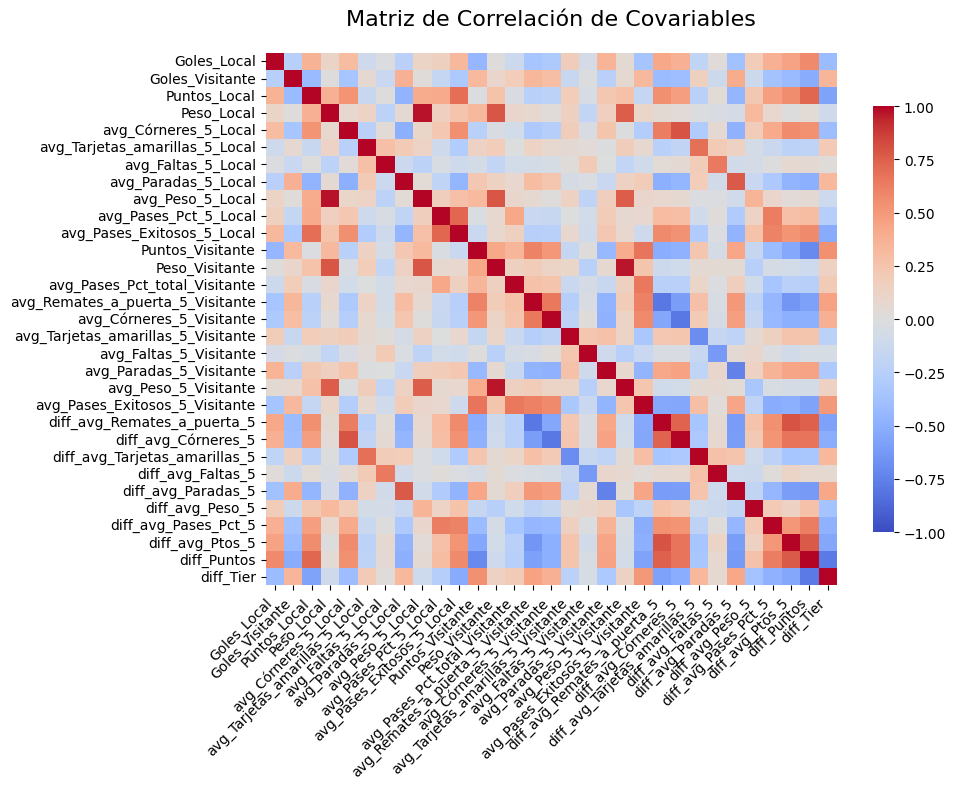

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

exclude = [
    'Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado', 'Resultado_Prorroga', 'Resultado_Penaltis', 'Resultado_1X2', 'Tipo_Equipo', 
    'Continente_Local', 'Continente_Visitante', 'Prob_Implicita_ELO'
]

# 1. Calcular la matriz de correlación (método de Pearson por defecto)
covariables = [x for x in df_reduced.columns if x not in exclude]
matriz_corr = df_reduced[covariables].corr()

# 3. Configurar el tamaño del lienzo (hazlo más grande si tienes muchas variables)
plt.figure(figsize=(10, 8)) 

# 4. Dibujar el Heatmap con Seaborn
sns.heatmap(
    matriz_corr, 
    cmap="coolwarm",       # Paleta clásica: Rojo (correlación positiva), Azul (negativa)
    vmin=-1, vmax=1,       # Fija los límites de la escala de color estandarizada
    cbar_kws={"shrink": .8} # Ajusta el tamaño de la barra lateral de leyenda
)

# 5. Títulos y ajustes finales
plt.title("Matriz de Correlación de Covariables", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Rota las etiquetas de abajo para que se lean bien
plt.tight_layout()
plt.show()

In [141]:
# Elimina columnas que contengan 'avg_Peso_2' o 'avg_Peso_5' ya que son redundantes (el Peso es constante)
pattern = r'avg_Peso_2|avg_Peso_5|Puntos_Local|Puntos_Visitante'
df_reduced = df_reduced.loc[:, ~df_reduced.columns.str.contains(pattern, regex=True)]
print(df_reduced.shape)

(1420, 31)


## Guardar Datasets

In [142]:
# --- Guardamos dataset del mundial 

# 1. Definimos la fecha que actuará como frontera
fecha_corte = pd.to_datetime('2026-06-10')

# 2. Creamos el dataset con los datos DESPUÉS (o el mismo día) de la fecha de corte
df_mundial = long_df[long_df['Fecha'] >= fecha_corte].copy()

# 3. Creamos el dataset con los datos ANTES de la fecha de corte
df_reduced = df_reduced[df_reduced['Fecha'] < fecha_corte].copy()

# Comprobación de que no hemos perdido filas por el camino
print(f"Filas en df: {len(df_reduced)}")
print(f"Filas en df_mundial: {len(df_mundial)}")

Filas en df: 1396
Filas en df_mundial: 48


In [144]:
df_reduced.to_csv('../Data/datos_historicos.csv', index=False)
df_mundial.to_csv('../Data/datos_mundial.csv', index=False)